# Worst Case Headway Time Experiments (Real-World)

In [1]:
from typing import Dict, List, Tuple
from collections import defaultdict

import copy
import csv
import itertools
import math
import os
import pickle

import pandas
import plotly
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy.special import erfinv

from policies import *
from routes import *
from wc_analysis import *
from prob_analysis import *

## Plotting Helpers

In [9]:
def plot_headway(results, sim_results) -> None:
    
    
    fig = go.Figure()
    whitespace = 0.2
    width = (1 - whitespace) / len(results.keys())
    for i, name in enumerate(results.keys()):

        #sim = {}
        #with open(sim_results[name], 'rb') as results_f:
        #    sim = pickle.loads(results_f.read())
        #results[name]['simulation'] = {}
        #results[name]['simulation']['headway'] = [[] for _ in range(len(results[name]['route']))]
        #for stp in sim['headway']:
        #    for jdx, stop in enumerate(results[name]['route']):
        #        if stp == stop["stop_id"]:
        #            results[name]['simulation']['headway'][jdx] = [s / 60 for s in sim['headway'][stp]]
        
        
        #offset = -0.5 + 0.5 * whitespace + i * width + 0.5 * width
        #for stop_idx in range(len(results[name]['route'])):
            #fig.add_trace(go.Bar(
            #    y=[results[name]['worst_case']['headway'][stop_idx]],
            #    x=[stop_idx + offset],
            #    base=[results[name]['best_case']['headway'][stop_idx]],
            #    width=width,
            #    opacity=0.5,
            #    marker={'color': px.colors.qualitative.T10[i]},
            #    name=name,
            #    showlegend=True if stop_idx == 0 else False,
            #))
        fig.add_trace(go.Scatter(
            y=results[name]['worst_case']['headway'],
            x=[s for s in range(len(results[name]['route']))],
            mode="lines",
            line_color=px.colors.qualitative.T10[i],
            showlegend=False,
        ))
        fig.add_trace(go.Scatter(
            y=results[name]['best_case']['headway'],
            x=[s for s in range(len(results[name]['route']))],
            mode="lines",
            line_color=px.colors.qualitative.T10[i],
            fill="tonexty",
            name=name,
            showlegend=True,
        ))
            #fig.add_trace(go.Box(
            #    y=results[name]['simulation']['headway'][stop_idx],
            #   x=[stop_idx + offset] * len(results[name]['simulation']['headway'][stop_idx]),
            #    showlegend=False,
            #    width=width,
            #    marker={'color':px.colors.qualitative.T10[i]},
            #))

    fig.update_yaxes(
        title_text='Headway Bounds (min.)',
    )


    control_points = [(0, 'Hickory Hollow'), (7, 'Bell'), (19, 'Glengarry'), (20, 'Thompson'), (40, 'City Center'), (56, 'Thompson')]
    for pt, _ in control_points:
        fig.add_vline(
            x=pt,
            line_width=2,
            line_dash="dash",
            line_color="black",
        )
    xticks = ['' for j in range(len(results[name]['route']))]
    xticks[19] = 'Glengarry'
    xticks[20] = 'Thompson'
    xticks[0] = 'Hickory Hollow'
    xticks[7] = 'Bell'
    xticks[56] = 'Thompson'
    xticks[40] = 'City Center'
    fig.update_layout(
        xaxis=dict(
            tickmode='array',
            tickvals=[i for i in range(len(xticks))],
            ticktext=xticks,
            tickangle=45,
            #title='Stop #',
        ), 
        legend=dict(
            xanchor='right',
            x=1.2
        ),
        font_family="Times New Roman, serif",
    )

    fig.show()

def run_experiment(exp_id: str, routes: Dict, sim_results: Dict, start_times: List[List[float]], t_max: int = 60 * 24 * 7) -> None:
    results = {}
    for name, route in routes.items():
        print(f'Working on {name}...')
        wc_headway, bc_headway = wcht(route_factory(route), start_times, t_max)
        #wc_travel = []
        #for i in range(len(route)):
        #    wc_travel.append([])
        #    for j in range(len(route)):
        #        wc_travel[i].append(wctt(route_factory(route), start_times, wc_headway, i, j))
        #prob_results = simulate(route_factory(route), start_times, t_max, seed=0)
        results[name] = {
            'worst_case': {'headway': wc_headway}, #'travel': wc_travel},
            'best_case': {'headway': bc_headway},
            #'simulation': prob_results,
            'route': route
        }

    plot_headway(results, sim_results)
    #plot_travel(results)

In [10]:
def plot_travel(results):
    fig = make_subplots(
        rows=2,
        cols=len(results.keys()),
        column_titles=list(results.keys()),
        row_titles=['Upper Bound', 'Actual'],
        x_title="To Stop #",
        y_title="Worst Case Trave Time From Stop #"
    )

    # Normalize Color Scales
    absolute_max = 0
    absolute_min = 1e6
    for name in results.keys():
        for i in results[name]['worst_case']['travel']:
            absolute_max = max(absolute_max, max(i))
            absolute_min = min(absolute_min, min(i))
        #for i in results[name]['simulation']['travel']:
        #    for j in i:
        #        absolute_max = max(absolute_max, max(j))
        #        absolute_min = min(absolute_min, min(j))
    
    # Plot The Thing
    for i, name in enumerate(results.keys()):
        fig.add_trace(
            go.Heatmap(
                z=results[name]['worst_case']['travel'],
                text=results[name]['worst_case']['travel'],
                texttemplate="%{text:.0f}",
                showscale=False,
                zmax=absolute_max,
                zmin=absolute_min,
                #textfont={"size":10}
            ),
            row=1,
            col=i + 1,
        )
    #for i, name in enumerate(results.keys()):
    #    z = [[max(k) for k in j] for j in results[name]['simulation']['travel']]
    #    fig.add_trace(
    #        go.Heatmap(
    #            z=z,
    #            text=z,
    #            texttemplate="%{text:.0f}",
    #            showscale=False,
    #            zmax=absolute_max,
    #            zmin=absolute_min,
    #            #textfont={"size":10}
    #       ),
    #        row=2,
    #        col=i + 1,
    #    )

    fig.show()

## Load the GTFS

In [11]:
def get_quantile_log_normal(mu: float, sigma: float, p: float) -> float:
    return math.exp(mu + math.sqrt(2 * sigma ** 2) * erfinv(2 * p - 1))

def get_log_normal_mixture(mu: list[float], sigma: list[float], weights: list[float] = None) -> tuple[float]:
    """Get the parameters of a log normal mixture approximated by log normal distribution."""
    # Calculate moments
    assert len(mu) == len(sigma)

    if weights is None:
        w = [1 / len(mu) for _ in range(len(mu))]
    else:
        w = weights

    m1 = 0
    m2 = 0
    for i in range(len(mu)):
        m1 += w[i] * math.exp(mu[i] + (sigma[i] ** 2) / 2)
        m2 += (w[i] ** 2) * math.exp(2 * mu[i] + 2 * sigma[i] ** 2)
    temp = 0
    for i in range(len(sigma)):
        for j in range(i+1,len(sigma)):
            temp += (w[i] * w[j]) * math.exp(mu[i] + mu[j] + 0.5 * (sigma[i] ** 2 + sigma[j] ** 2))
    m2 = m2 + 2 * temp

    # Calculate new parameters
    sigma = math.sqrt(math.log(m2/(m1 ** 2)))
    mu = math.log(m1) - (sigma ** 2) / 2
    return mu, sigma


In [16]:
def read_GTFS(
    lower_quantile: float, upper_quantile: float, service_day: str = "monday", route_id: str = "55"
) -> tuple[list[dict], list[list[float]], list[float]]:

    pattern_by_direction: dict[str, tuple[Stop, ...]] = {}

    gtfs_path = "GTFS"
    with open(os.path.join(gtfs_path, "calendar.txt"), encoding="utf-8") as f:
        calendar = list(csv.DictReader(f))
    with open(os.path.join(gtfs_path, "trips.txt"), encoding="utf-8") as f:
        trips = list(csv.DictReader(f))
    with open(os.path.join(gtfs_path, "stop_times.txt"), encoding="utf-8") as f:
        stop_times = list(csv.DictReader(f))
    with open(os.path.join(gtfs_path, "stops.txt"), encoding="utf-8") as f:
        stops = list(csv.DictReader(f))

    times_path = "DATA"
    travel_times = pandas.read_csv(os.path.join(times_path, "travel_times.csv"))
    alight_rates = pandas.read_csv(os.path.join(times_path, "alight_rates.csv"))
    demand_rates = pandas.read_csv(os.path.join(times_path, "demand_rates_monday.csv"))
    
    # find service ID for given day of week
    active_service_ids = [service["service_id"] for service in calendar if service[service_day] == "1"]
    if not active_service_ids:
        raise ValueError(f"No service specified for '{service_day}' in calendar.txt")

    # TODO: handle multiple service IDs and exception (not required for current experiments)
    assert len(active_service_ids) == 1, f"Expected only one service ID, but found {len(active_service_ids)}: {active_service_ids}"
    # TODO: also filter by specific date range (not required for current WeGo GTFS)
    service_id = active_service_ids[0]

    # map trip ID to stop times (i.e., sequence of scheduled stops)
    stop_times_by_trip_ID = defaultdict(list)
    for stop_time in stop_times:
        # convert stop_sequence field to integer
        stop_time["stop_sequence"] = int(stop_time["stop_sequence"])
        # convert arrival_time field to float
        h, m, s = stop_time["departure_time"].strip().split(':')
        stop_time["departure_time"] = int(h) * 60 + int(m) + int(s) / 60
        stop_times_by_trip_ID[stop_time["trip_id"]].append(stop_time)

    # for each trip, sort stop times by sequence numbers
    sorted_stop_times_by_trip_ID = {}
    for trip_ID in stop_times_by_trip_ID:
        sorted_stop_times_by_trip_ID[trip_ID] = sorted(
            stop_times_by_trip_ID[trip_ID],
            key=lambda stop_time: stop_time["stop_sequence"],
        )

    # map block ID to active trips
    trips_by_block_ID = defaultdict(list)
    for trip in trips:
        # check if the trip is active (i.e., active service) and on the selected route
        if trip["service_id"] == service_id and trip["route_id"] == route_id:
            trips_by_block_ID[trip["block_id"]].append(trip)

    # map patterns (i.e., unique sequences of stops) to trips
    patterns_by_direction_ID = defaultdict(set)
    trips_by_pattern = defaultdict(list)
    for block_ID in trips_by_block_ID:
        for trip in trips_by_block_ID[block_ID]:
            pattern = tuple(stop_time["stop_id"] for stop_time in sorted_stop_times_by_trip_ID[trip["trip_id"]])
            patterns_by_direction_ID[trip["direction_id"]].add(pattern)
            trips_by_pattern[pattern].append(trip)

    # TODO: handle multiple patterns per direction (not required for current experiments)
    # select the most common pattern for each direction ID
    selected_pattern_by_direction_ID = {}
    for direction_ID in ["0", "1"]:
        patterns = patterns_by_direction_ID[direction_ID]
        selected_pattern = max(patterns, key=lambda pattern: len(trips_by_pattern[pattern]))
        selected_pattern_by_direction_ID[direction_ID] = selected_pattern

    # select the trips that follow these patterns
    selected_trip_ID = set(
        trip["trip_id"] for direction_ID in ["0", "1"] for trip in trips_by_pattern[selected_pattern_by_direction_ID[direction_ID]]
    )

    # map (stop ID, direction ID) to Stop objects
    stop_info: list[dict] = []
    for direction_id in ["1", "0"]:
        pattern = selected_pattern_by_direction_ID[direction_id]
        for sid in pattern[:-1]: # Last stop in pattern is duplicated, since it is first start of next direction
            stop_info.append({
                'stop_id': sid,
                'tau': None,
                'delta': None,
                'policy': BolehPolicy,
                'policy_args': {},
            })
    #stop_info = stop_info[:-1]

    # Get scheduled departures for each stop
    scheduled_departure_times = {}
    for direction_id in ["0", "1"]:
        pattern = selected_pattern_by_direction_ID[direction_id]
        for idx, sid in enumerate(pattern):
            scheduled_departure_times[sid] = []
            for trip in trips_by_pattern[pattern]:
                #for stop_time in sorted_stop_times_by_trip_ID[trip["trip_id"]]:
                departure_time = sorted_stop_times_by_trip_ID[trip["trip_id"]][idx]["departure_time"]
                scheduled_departure_times[sid].append(departure_time)
    for sid in scheduled_departure_times:
        scheduled_departure_times[sid].sort()

    # Get starting times
    direction_ID = "0"
    block_start_times = {}
    for trip in trips_by_pattern[selected_pattern_by_direction_ID[direction_id]]:
        proposed_block_start = sorted_stop_times_by_trip_ID[trip["trip_id"]][0]["departure_time"]
        if trip["block_id"] not in block_start_times:
            block_start_times[trip["block_id"]] = proposed_block_start
        elif block_start_times[trip["block_id"]] > proposed_block_start:
            block_start_times[trip["block_id"]] = proposed_block_start
    block_start_times = sorted(list(block_start_times.values()))

    # Normalize all times
    offset = block_start_times[0]
    for idx, time in enumerate(block_start_times):
        block_start_times[idx] -= offset
        if block_start_times[idx] >= 200:
            block_start_times = block_start_times[:idx]
            break
    for departure_times in scheduled_departure_times.values():
        for idx, _ in enumerate(departure_times):
            departure_times[idx] -= offset
        

    for stop in stop_info:
        tt = travel_times[(travel_times.day_of_week == "Monday") & (travel_times.from_stop_id == stop["stop_id"])]
        tt_mu = list(tt.mean_log_travel_time_s)
        tt_sigma = list(tt.std_log_travel_time_s)
        mu, sigma = get_log_normal_mixture(tt_mu, tt_sigma)
        lower = get_quantile_log_normal(mu, sigma, lower_quantile) / 60
        upper = get_quantile_log_normal(mu, sigma, upper_quantile) / 60
        stop["tau"] = (lower, upper)

        ar = alight_rates[alight_rates.STOP_ID == stop["stop_id"]]
        ar = list(ar.ALIGHT_RATE)
        dr = demand_rates[demand_rates.STOP_ID == stop["stop_id"]]
        dr = list(dr.HOURLY_DEMAND)

        weights = []
        for a, d in zip(ar, dr):
            weights.extend([10 / len(ar), 2 * a / len(ar), 3.5 * d / len(dr)])
        mu, sigma = get_log_normal_mixture([0 for _ in range(len(weights))], [0.1 for _ in range(len(weights))], weights)
        lower = get_quantile_log_normal(mu, sigma, lower_quantile) / 60
        upper = get_quantile_log_normal(mu, sigma, upper_quantile) / 60
        stop["delta"] = (lower, upper)
    
    return stop_info, scheduled_departure_times, block_start_times

stop_info, departures, start = read_GTFS(lower_quantile=0.01, upper_quantile=0.80)
#print(departures['HICHICNN'])
#print(start)
#stop_info

Working on $\pi\texttt{SCH}$...
Working on $\pi\texttt{DYN}\;@\text{Control Points}$...
Working on $\text{Policy Mixture}$...
Working on $\pi\texttt{DYN}\;@\text{Every Stop}$...


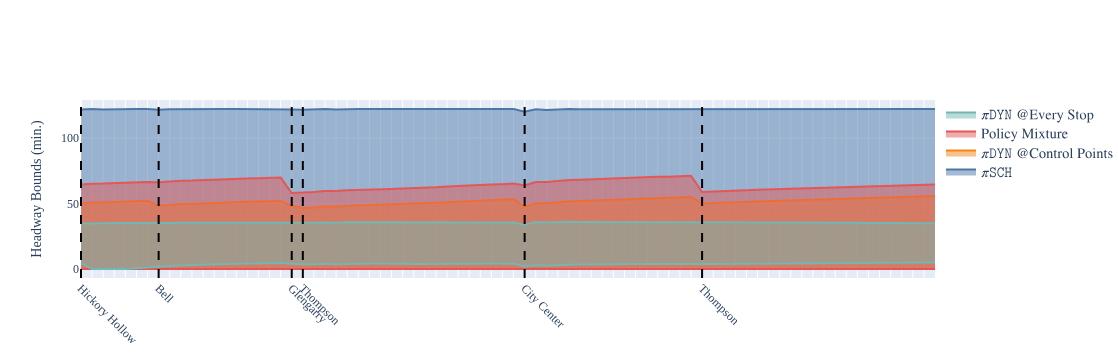

In [17]:
# Base route - no control
BASE_ROUTE = stop_info

# Possible Control Points
CTRLPTS = ['HICHICNN', 'MXIGLENG', 'MXITHOMP', 'MXIBELL', 'MCC4_15', 'MXOTHOMP']

# Sched Driven Route
SCHED_ROUTE= copy.deepcopy(BASE_ROUTE)
for i in range(len(SCHED_ROUTE)):
    if SCHED_ROUTE[i]['stop_id'] in CTRLPTS:
        SCHED_ROUTE[i]['policy'] = ScheduleDrivenPolicy
        SCHED_ROUTE[i]['policy_args'] = {'schedule': departures[SCHED_ROUTE[i]['stop_id']]}

# Sched Driven Route
ALL_ROUTE= copy.deepcopy(BASE_ROUTE)
for i in range(len(ALL_ROUTE)):
    ALL_ROUTE[i]['policy'] = RatioDrivenPolicy
    ALL_ROUTE[i]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': float('inf')}

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE = copy.deepcopy(BASE_ROUTE)
for i in range(len(RATIO_ROUTE)):
    if RATIO_ROUTE[i]['stop_id'] in CTRLPTS:
        RATIO_ROUTE[i]['policy'] = RatioDrivenPolicy
        RATIO_ROUTE[i]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': float('inf')}

PROPOSED_ROUTE = copy.deepcopy(BASE_ROUTE)
for i in range(len(PROPOSED_ROUTE)):
    if PROPOSED_ROUTE[i]['stop_id'] in ['MXIGLENG', 'MXOTHOMP']:
        PROPOSED_ROUTE[i]['policy'] = RatioDrivenPolicy
        PROPOSED_ROUTE[i]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': float('inf')}
    if PROPOSED_ROUTE[i]['stop_id'] in ['HICHICNN', 'MCC4_15']:
        PROPOSED_ROUTE[i]['policy'] = ScheduleDrivenPolicy
        PROPOSED_ROUTE[i]['policy_args'] = {'schedule': departures[PROPOSED_ROUTE[i]['stop_id']]}

routes = {
    r'$\pi\texttt{SCH}$': SCHED_ROUTE,
    r'$\pi\texttt{DYN}\;@\text{Control Points}$': RATIO_ROUTE,
    r'$\text{Policy Mixture}$': PROPOSED_ROUTE,
    r'$\pi\texttt{DYN}\;@\text{Every Stop}$': ALL_ROUTE,
}
sim_results = {
    'H/T Ratio Driven': 'sim_r55_ffa.pkl',
}

run_experiment(
    exp_id='exp-base',
    routes=routes,
    sim_results=sim_results,
    start_times=start,
    t_max=60 * 48,
)

In [ ]:
stop_info[20]

## Load the Simulated Data

In [50]:
results = {}
with open('sim_r55_ffa.pkl', 'rb') as results_f:
    results = pickle.loads(results_f.read())
list(results.keys())
list(results['headway'][50])

[]

## Plot the Data